In [113]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [114]:
df = pd.read_csv("House Price Prediction Dataset.csv")

In [115]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [116]:
df.shape

(2000, 10)

In [117]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [119]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [120]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [121]:
df.duplicated().sum()

np.int64(0)

In [122]:
df = df.drop("Id", axis=1)

In [123]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


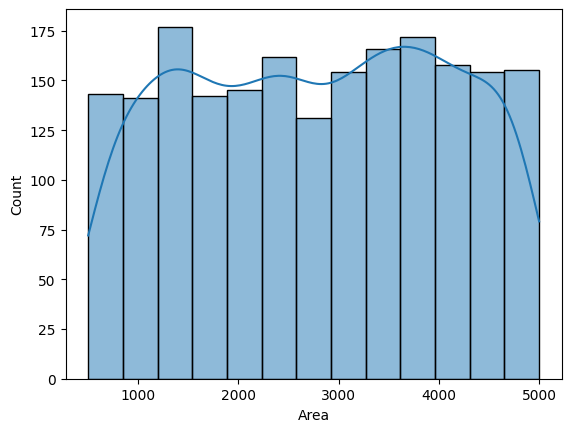

In [124]:
sns.histplot(x = df["Area"], kde= True)
plt.show()

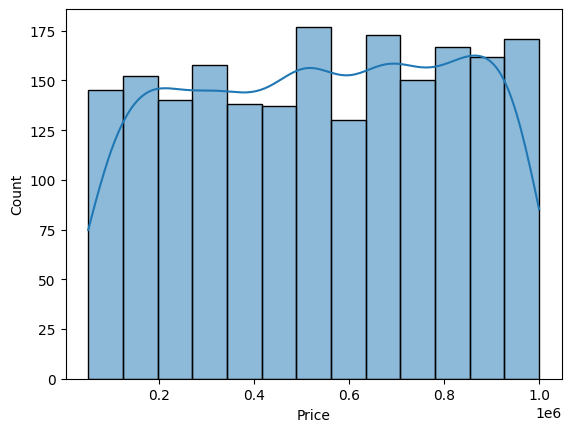

In [125]:
sns.histplot(x = df["Price"], kde= True)
plt.show()

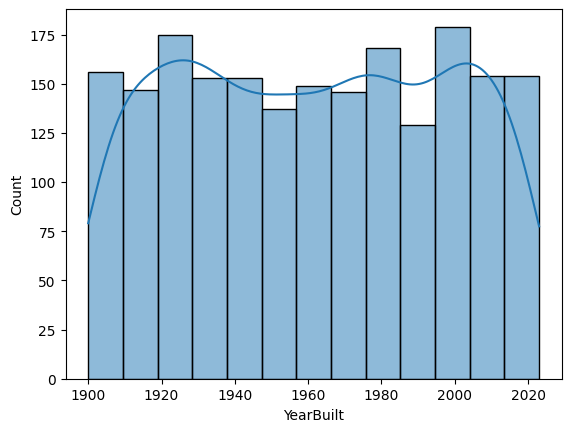

In [126]:
sns.histplot(x = df["YearBuilt"], kde= True)
plt.show()

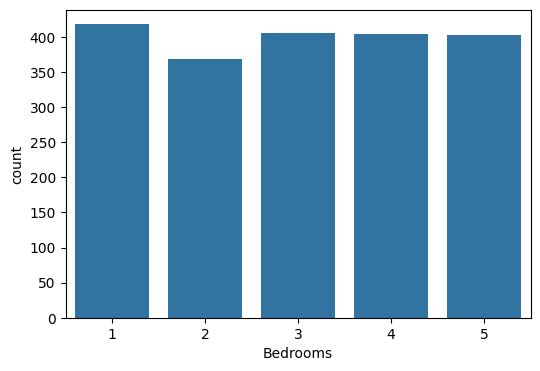

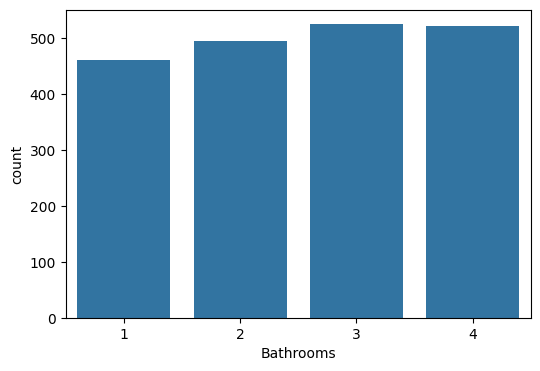

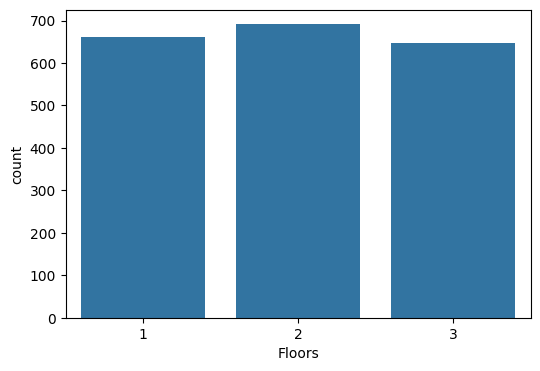

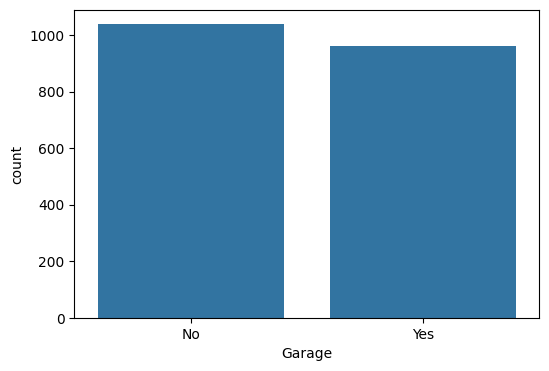

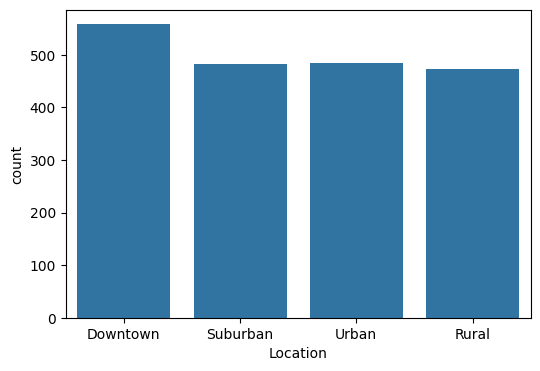

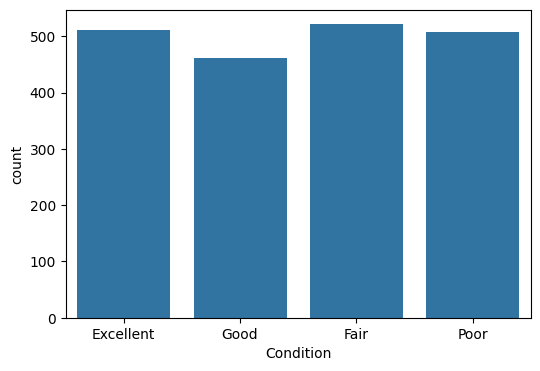

In [127]:
categorical_columns = ['Bedrooms','Bathrooms', 'Floors', 'Garage', 
                       'Location', 'Condition']
for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x = df[col])

In [128]:
df["Garage"] = df["Garage"].map({"Yes": 1, "No": 0})

In [129]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,0,149919
1,4272,5,4,3,1958,Downtown,Excellent,0,424998
2,3592,2,2,3,1938,Downtown,Good,0,266746
3,966,4,2,2,1902,Suburban,Fair,1,244020
4,4926,1,4,2,1975,Downtown,Fair,1,636056


In [130]:
df = pd.get_dummies(df,columns = ['Location','Condition'],drop_first=True)

In [131]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Garage,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor
0,1360,5,4,3,1970,0,149919,False,False,False,False,False,False
1,4272,5,4,3,1958,0,424998,False,False,False,False,False,False
2,3592,2,2,3,1938,0,266746,False,False,False,False,True,False
3,966,4,2,2,1902,1,244020,False,True,False,True,False,False
4,4926,1,4,2,1975,1,636056,False,False,False,True,False,False


In [132]:
df = df.astype(int)

In [133]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Garage,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor
0,1360,5,4,3,1970,0,149919,0,0,0,0,0,0
1,4272,5,4,3,1958,0,424998,0,0,0,0,0,0
2,3592,2,2,3,1938,0,266746,0,0,0,0,1,0
3,966,4,2,2,1902,1,244020,0,1,0,1,0,0
4,4926,1,4,2,1975,1,636056,0,0,0,1,0,0


In [134]:
from sklearn.preprocessing import StandardScaler
cols = ['Area','Bedrooms','Bathrooms','Floors','YearBuilt']
scaler = StandardScaler()

df[cols] = scaler.fit_transform(df[cols])

In [135]:
df_cleaned = df.copy()

In [136]:
df_cleaned.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Garage,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor
0,-1.101471,1.401791,1.305568,1.244151,0.238155,0,149919,0,0,0,0,0,0
1,1.147485,1.401791,1.305568,1.244151,-0.095942,0,424998,0,0,0,0,0,0
2,0.622317,-0.704581,-0.498326,1.244151,-0.652770,0,266746,0,0,0,0,1,0
3,-1.405759,0.699667,-0.498326,0.008035,-1.655061,1,244020,0,1,0,1,0,0
4,1.652574,-1.406705,1.305568,0.008035,0.377363,1,636056,0,0,0,1,0,0


In [137]:
df_cleaned.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Garage',
       'Price', 'Location_Rural', 'Location_Suburban', 'Location_Urban',
       'Condition_Fair', 'Condition_Good', 'Condition_Poor'],
      dtype='object')

In [138]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Garage',
       'Location_Rural', 'Location_Suburban', 'Location_Urban',
       'Condition_Fair', 'Condition_Good', 'Condition_Poor'
]

# Calculate Pearson correlation
correlations = {
    feature: pearsonr(df[feature], df_cleaned['Price'])[0]
    for feature in selected_features
}

# Convert to DataFrame for display
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])

# Show the results
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
3,Floors,0.055890
9,Condition_Fair,0.049218
7,Location_Suburban,0.040303
4,YearBuilt,0.004845
5,Garage,0.002842
6,Location_Rural,0.001890
0,Area,0.001542
1,Bedrooms,-0.003471
2,Bathrooms,-0.015737
10,Condition_Good,-0.017179


In [139]:
cat_features = [
    'Garage','Location_Rural', 'Location_Suburban', 'Location_Urban',
       'Condition_Fair', 'Condition_Good', 'Condition_Poor'
]

In [140]:
from scipy.stats import chi2_contingency
import pandas as pd

# Define significance level
alpha = 0.05

# Bin the target variable
df_cleaned['price_bin'] = pd.qcut(df_cleaned['Price'], q=4, labels=False)

# Run Chi-Square test
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['price_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

# Convert to DataFrame
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df


,chi2_statistic,p_value,Decision
Location_Suburban,12.345932,0.006287,Reject Null (Keep Feature)
Condition_Fair,7.192181,0.066018,Accept Null (Drop Feature)
Condition_Poor,6.116644,0.106071,Accept Null (Drop Feature)
Location_Urban,5.125379,0.162843,Accept Null (Drop Feature)
Condition_Good,4.654119,0.198948,Accept Null (Drop Feature)
Location_Rural,4.634161,0.200631,Accept Null (Drop Feature)
Garage,1.898742,0.593687,Accept Null (Drop Feature)


In [162]:
from sklearn.model_selection import train_test_split

In [163]:
X = df_cleaned.drop(['Price','price_bin'], axis=1)
y = df_cleaned['Price']

In [164]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [165]:
X_train

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Garage,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor
968,1.310442,0.699667,1.305568,1.244151,-0.791977,0,0,0,1,0,0,0
240,-1.331618,-0.002457,0.403621,-1.228081,0.238155,0,0,0,0,0,1,0
819,-1.053588,-0.002457,1.305568,-1.228081,0.878508,1,0,0,1,0,1,0
692,-0.099017,-0.704581,0.403621,-1.228081,0.293838,1,1,0,0,0,0,1
420,0.385991,-0.704581,1.305568,-1.228081,0.544411,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1130,0.538136,1.401791,0.403621,1.244151,-0.847660,1,0,0,0,0,1,0
1294,-0.802588,-0.002457,0.403621,0.008035,-0.569246,1,0,0,0,1,0,0
860,-1.005705,-0.704581,0.403621,1.244151,0.321680,0,0,0,0,0,1,0
1459,0.517283,1.401791,1.305568,-1.228081,-0.179466,1,0,0,0,0,1,0


In [166]:
y_train

968     434325
240     614772
819     922811
692     794314
420     796988
         ...  
1130    387088
1294    942215
860     323139
1459    274997
1126    644206
Name: Price, Length: 1600, dtype: int64

In [167]:
X_test

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Garage,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor
1860,-1.662937,-1.406705,1.305568,0.008035,-1.682902,0,0,0,1,1,0,0
353,0.826206,-1.406705,-1.400273,0.008035,-1.682902,0,0,0,1,1,0,0
1333,-0.917662,1.401791,1.305568,-1.228081,1.435336,0,0,0,1,0,0,0
905,-0.835025,-0.002457,-1.400273,0.008035,0.962032,1,0,0,0,0,1,0
1289,-0.171614,1.401791,-0.498326,1.244151,0.906349,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
965,-0.753160,-1.406705,0.403621,1.244151,0.238155,0,1,0,0,0,0,1
1284,-1.538596,-0.002457,-0.498326,0.008035,1.435336,1,0,0,0,0,0,1
1739,0.582157,0.699667,1.305568,0.008035,-0.624928,1,0,0,0,0,0,1
261,0.682557,1.401791,-0.498326,0.008035,-1.432330,1,0,0,0,0,1,0


In [168]:
y_test

1860    514764
353     694256
1333     66375
905     650243
1289    223285
         ...  
965     386940
1284    632570
1739    494049
261     562193
535     447530
Name: Price, Length: 400, dtype: int64

In [148]:
y_pred_lr

array([521988.22189839, 549119.31196651, 487101.22235594, 539752.7439933 ,
       553242.24872512, 521375.92025826, 523320.18080583, 578133.64353335,
       545899.64738458, 577368.69940644, 549359.90237922, 583802.8656311 ,
       511024.20843161, 527181.17287186, 502178.93122353, 563657.42139779,
       533851.47058016, 557566.45545641, 578893.4890812 , 522197.01288502,
       535945.37429884, 520333.81440515, 520145.76012635, 589984.6964629 ,
       570910.91251258, 530657.68307139, 524849.79926253, 533833.03412407,
       517535.08657939, 489462.64631857, 471135.44970754, 532885.36922583,
       559703.53345149, 566918.76753933, 505186.85760171, 504126.65238569,
       566525.93875815, 587039.42913431, 533334.54147469, 503067.97932305,
       488794.10065586, 540580.91705316, 538165.7543287 , 538208.1073811 ,
       539782.8193264 , 574195.17961934, 551957.63060142, 537147.22385255,
       531554.19942009, 528480.27403638, 515181.27688738, 549393.77262824,
       567112.62323004, 5

Linear Regression

In [169]:
from sklearn.linear_model import LinearRegression

In [170]:
model_lr = LinearRegression()
model_lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [171]:
y_pred_lr = model_lr.predict(X_test)

In [172]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred_lr)
r2

-0.006717808430749761

Decision Tree

In [153]:
from sklearn.tree import DecisionTreeRegressor
model_DT = DecisionTreeRegressor(random_state=42)
model_DT.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [154]:
y_pred_DT = model_DT.predict(X_test)
r2 = r2_score(y_test,y_pred_DT)
r2

0.8846212346673185

Gradient Boosting

In [155]:
from sklearn.ensemble import GradientBoostingRegressor
model_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)
model_gb.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [156]:
y_pred_gb = model_gb.predict(X_test)
r2 = r2_score(y_test,y_pred_gb)
r2

0.9370025667065679

Random Forest

In [157]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [158]:
y_pred_rf = model_rf.predict(X_test)
r2 = r2_score(y_test,y_pred_rf)
r2

0.9349655844762942

In [159]:
df_cleaned.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Garage,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,price_bin
0,-1.101471,1.401791,1.305568,1.244151,0.238155,0,149919,0,0,0,0,0,0,0
1,1.147485,1.401791,1.305568,1.244151,-0.095942,0,424998,0,0,0,0,0,0,1
2,0.622317,-0.704581,-0.498326,1.244151,-0.652770,0,266746,0,0,0,0,1,0,0
3,-1.405759,0.699667,-0.498326,0.008035,-1.655061,1,244020,0,1,0,1,0,0,0
4,1.652574,-1.406705,1.305568,0.008035,0.377363,1,636056,0,0,0,1,0,0,2


In [160]:
df_cleaned.shape

(2000, 14)

In [161]:
corr = df_cleaned.corr(numeric_only=True)

print(corr['Price'].sort_values(ascending=False))

Price                1.000000
price_bin            0.968305
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
YearBuilt            0.004845
Garage               0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Location_Urban      -0.038312
Name: Price, dtype: float64
